In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import torch
from transformers import AutoImageProcessor, AutoModel
from PIL import Image
import pandas as pd
from torchvision import datasets, transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import umap
import data
from data import TransDataset
from sklearn.manifold import TSNE
from transformers import CLIPProcessor, CLIPModel

/home/kuniko/anaconda3/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-09-05 16:25:04.711404: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-05 16:25:05.214067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-09-05 16:25:05.385503: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDN

In [2]:
root = "../../dataset/CIFAKE/"
save_filepath = f'{root}train.csv'
df_train = pd.read_csv(save_filepath)
save_filepath = f'{root}test.csv'
df_test = pd.read_csv(save_filepath)

In [3]:
id_to_class = data.get_id_to_class()
class_labels = list(id_to_class.values())
num_class = len(class_labels)

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = TransDataset(df_test)

In [4]:
images, labels, reals = [], [], []
for i in range(len(dataset)):
    img, label, real = dataset[i]
    images.append(img)
    labels.append(label)
    reals.append(real)

In [5]:
#Load the model and processor
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
processor = AutoImageProcessor.from_pretrained('facebook/dinov2-small')
model = AutoModel.from_pretrained('facebook/dinov2-small').to(device)

#Extract the features
image_embeddings = []
with torch.no_grad():
    for img in tqdm(images):
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1)  
        image_embeddings.append(embedding.cpu().numpy().flatten())

100%|████████████████████████████████████████████████████████████████████████████| 20000/20000 [02:32<00:00, 131.25it/s]


In [7]:
image_embeddings = np.array(image_embeddings)
labels = np.array(labels)
reals = np.array(reals)

In [8]:
def reduce_dim(reducer, model_name, reducer_name):
    embeddings_2d = reducer.fit_transform(image_embeddings)
    df_test['embeddings x'] = embeddings_2d[:,0]
    df_test['embeddings y'] = embeddings_2d[:,1]
    save_filepath = f'{root}distance/embed_{model_name}_{reducer_name}.csv'
    df_test.to_csv(save_filepath, index=False)
    return embeddings_2d

In [9]:
def plot_2d_embeddings(embeddings_2d, model_name, reducer_name):

    title = f"{model_name} Embeddings per Class by {reducer_name}"
    save_filepath = f'{root}figures/{model_name}_{reducer_name}.png'

    color_map = {0: "lightpink", 1: "lightblue"}
    rf_label_map = {0: "GEN", 1: "REAL"}
    centroid_color_map = {0: "red", 1: "blue"}
    
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    
    for i in range(num_class):
        ax = axes[i]
        area_dict = {}
        
        for rf in [1, 0]: # "0:FAKE", "1:REAL"
            subset = (labels == i) & (reals == rf)
            ax.scatter(
                embeddings_2d[subset, 0],
                embeddings_2d[subset, 1],
                label=rf_label_map[rf],
                color=color_map[rf],
                alpha=0.3,
                s=15
            )
    
            # centroid
            if subset.sum() > 0:
                centroid = embeddings_2d[subset].mean(axis=0)
                ax.scatter(
                    centroid[0], centroid[1],
                    color=centroid_color_map[rf],
                    marker='X',
                    s=100,
                    linewidth=0.8,
                    label=f"{rf_label_map[rf]} Centroid"
                )
    
                # radius: mean point of the mean point clouds
                dists = ((embeddings_2d[subset] - centroid)**2).sum(axis=1)**0.5
                radius = dists.mean()
                area_dict[rf] = np.pi * (radius ** 2) # area
    
                # circle
                circle = patches.Circle(
                    (centroid[0], centroid[1]),
                    radius,
                    color=centroid_color_map[rf],
                    alpha=0.2,
                    linestyle='--',
                    linewidth=1,
                    fill=True
                )
                ax.add_patch(circle)
            
        ax.set_title(f"{id_to_class[i]}")
        #if 0 in area_dict and 1 in area_dict:
        #    area_diff = area_dict[1] / area_dict[0] # fake / real
        #    ax.set_title(f"{id_to_class[i]}\nArea = {area_diff:.2f}", fontsize=14)
        #else:
        #    ax.set_title(f"{id_to_class[i]}", fontsize=14)
            
        ax.grid(True)
        ax.legend(fontsize=10)
    
    #plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.savefig(save_filepath)
    plt.show()

In [10]:
def save_distance(embeddings_2d, model_name, reducer_name):

    results = {}
    
    for i in range(len(class_labels)):  # Class
        results[i] = {}
        # REAL:1, FAKE:0
        subset = (labels == i) & (reals == 1)
        if subset.sum() == 0:
            continue
    
        points = embeddings_2d[subset]
        centroid = points.mean(axis=0).tolist()
        dists = ((points - centroid) ** 2).sum(axis=1) ** 0.5
        radius = dists.mean()
    
        f_subset = (labels == i) & (reals == 0)
        if f_subset.sum() == 0:
            continue
    
        f_points = embeddings_2d[f_subset]
        f_centroid = f_points.mean(axis=0).tolist()
        f_dists = ((f_points - f_centroid) ** 2).sum(axis=1) ** 0.5
        f_radius = f_dists.mean()
    
        results[i] = {
            'r centroid x': centroid[0],
            'r centroid y': centroid[1],
            'r radius': radius,
            'f centroid x': f_centroid[0],
            'f centroid y': f_centroid[1],
            'f radius': f_radius,
        }
    
    df_dino = pd.DataFrame(results).T
    df_dino.reset_index(inplace=True)
    df_dino.rename(columns={'index': 'label'}, inplace=True)
    
    save_filepath = f'{root}distance/dis_{model_name}_{reducer_name}.csv'
    df_dino.to_csv(save_filepath, index=False)

/home/kuniko/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


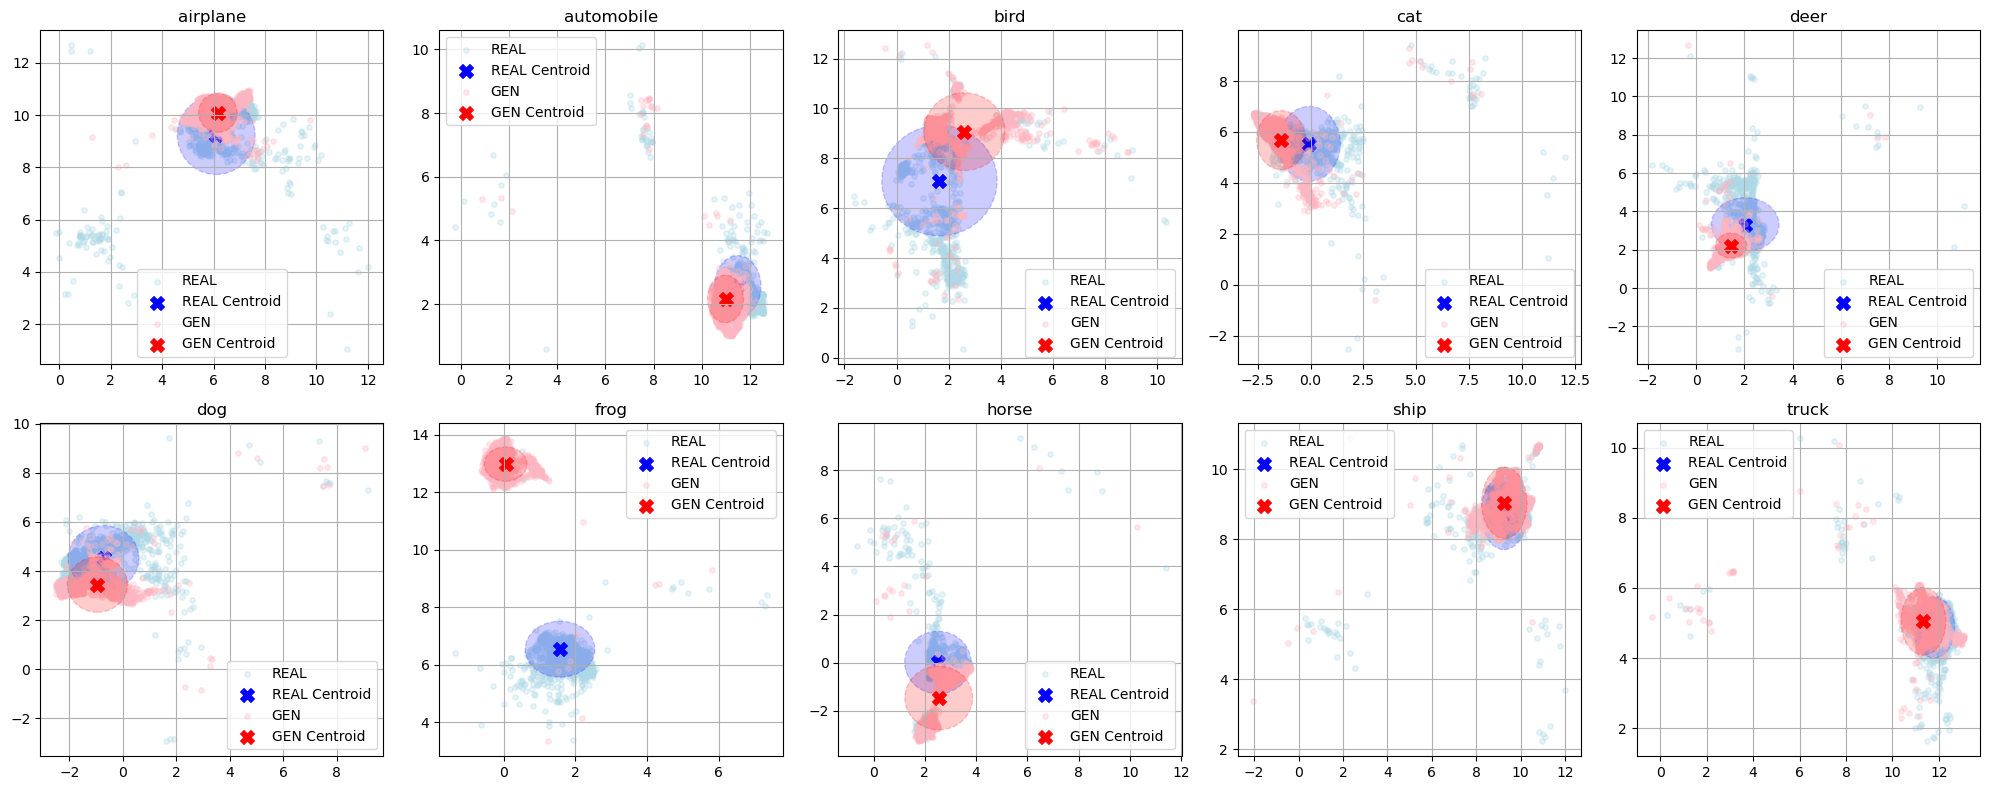

In [10]:
model_name = 'DINOv2'
reducer_name = 'UMAP'
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine")

embeddings_2d = reduce_dim(reducer, model_name, reducer_name)
plot_2d_embeddings(embeddings_2d, model_name, reducer_name)
save_distance(embeddings_2d, model_name, reducer_name)

/home/kuniko/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


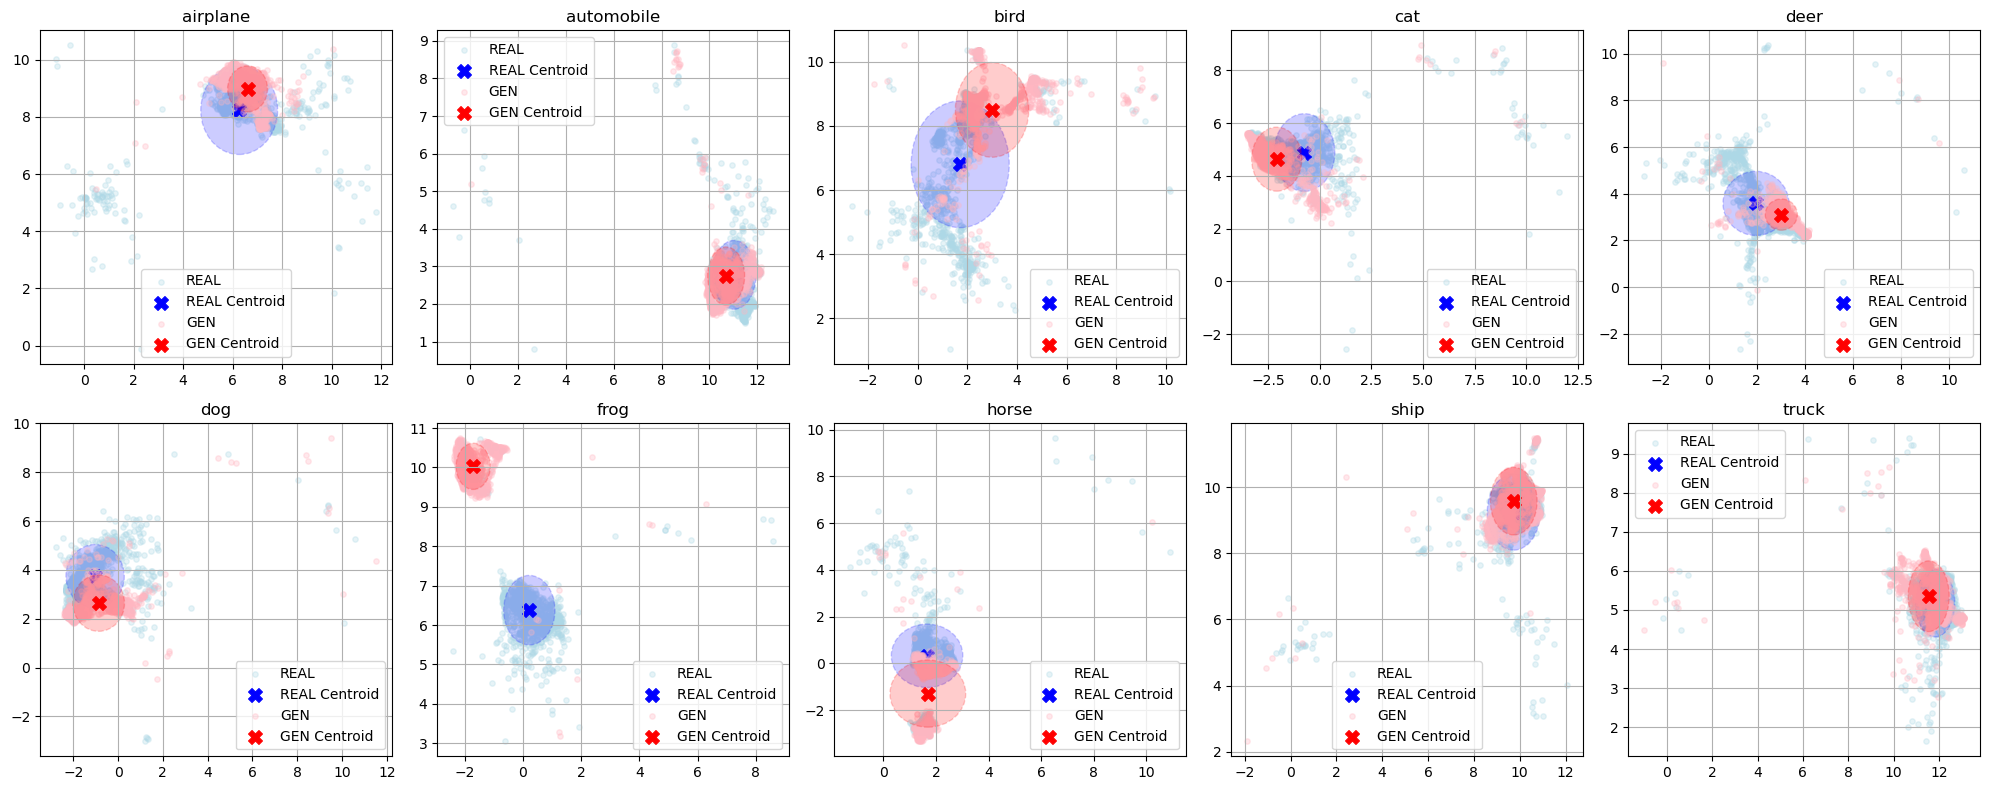

In [11]:
model_name = 'DINOv2'
reducer_name = 'TSNE'
tsne = TSNE(n_components=2, perplexity=30, metric="cosine", random_state=42)

embeddings_2d = reduce_dim(reducer, model_name, reducer_name)
plot_2d_embeddings(embeddings_2d, model_name, reducer_name)
save_distance(embeddings_2d, model_name, reducer_name)

# DINOv3

In [6]:
#Load the model and processor
device = torch.device('cuda' if torch.cuda.is_available() else "cpu")
pretrained_model_name = "facebook/dinov3-vits16-pretrain-lvd1689m"
processor = AutoImageProcessor.from_pretrained(pretrained_model_name)
model = AutoModel.from_pretrained(pretrained_model_name).to(device)

#Extract the features
image_embeddings = []
with torch.no_grad():
    for img in tqdm(images):
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model(**inputs)
        embedding = outputs.last_hidden_state.mean(dim=1)  
        image_embeddings.append(embedding.cpu().numpy().flatten())

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/585 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.4M [00:00<?, ?B/s]

100%|█████████████████████████████████████████████████████████████████████████████| 20000/20000 [12:19<00:00, 27.06it/s]


/home/kuniko/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


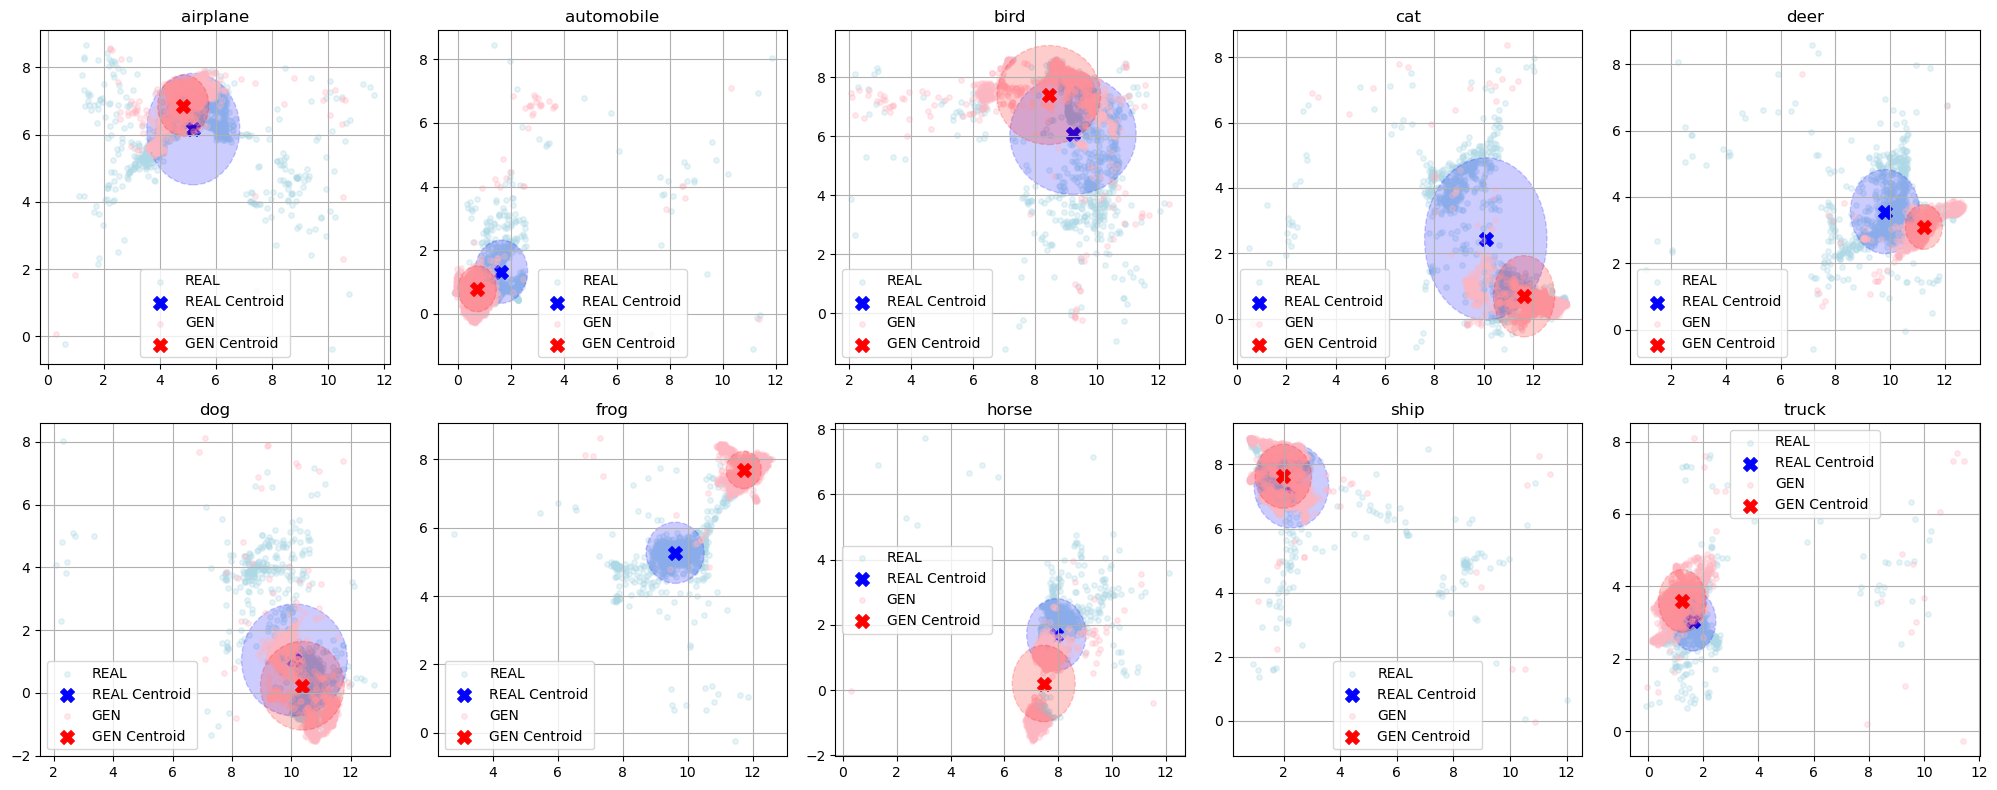

In [11]:
model_name = 'DINOv3'
reducer_name = 'UMAP'
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine")

embeddings_2d = reduce_dim(reducer, model_name, reducer_name)
plot_2d_embeddings(embeddings_2d, model_name, reducer_name)
save_distance(embeddings_2d, model_name, reducer_name)

/home/kuniko/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


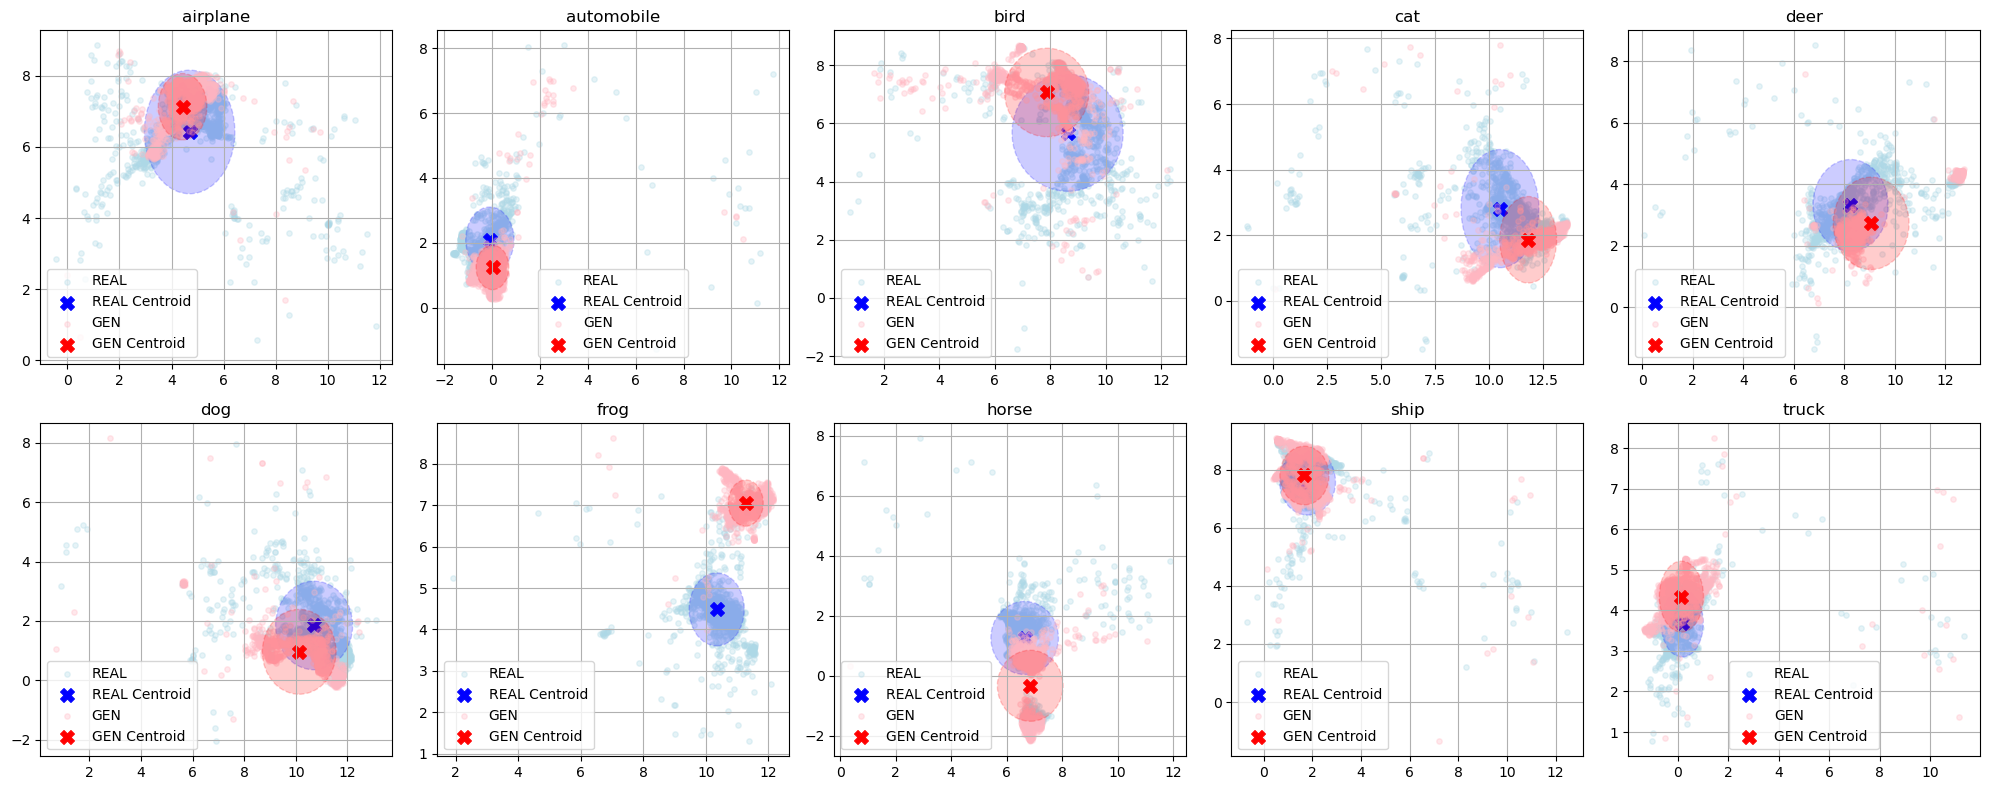

In [12]:
model_name = 'DINOv3'
reducer_name = 'TSNE'
tsne = TSNE(n_components=2, perplexity=30, metric="cosine", random_state=42)

embeddings_2d = reduce_dim(reducer, model_name, reducer_name)
plot_2d_embeddings(embeddings_2d, model_name, reducer_name)
save_distance(embeddings_2d, model_name, reducer_name)

# CLIP

In [12]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

In [13]:
image_embeddings = []
with torch.no_grad():
    for img in tqdm(images):
        inputs = processor(images=img, return_tensors="pt").to(device)
        outputs = model.get_image_features(**inputs)
        image_embeddings.append(outputs.cpu().numpy().flatten())

100%|████████████████████████████████████████████████████████████████████████████| 20000/20000 [02:30<00:00, 132.92it/s]


In [14]:
image_embeddings = np.array(image_embeddings)
labels = np.array(labels)
reals = np.array(reals)

/home/kuniko/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


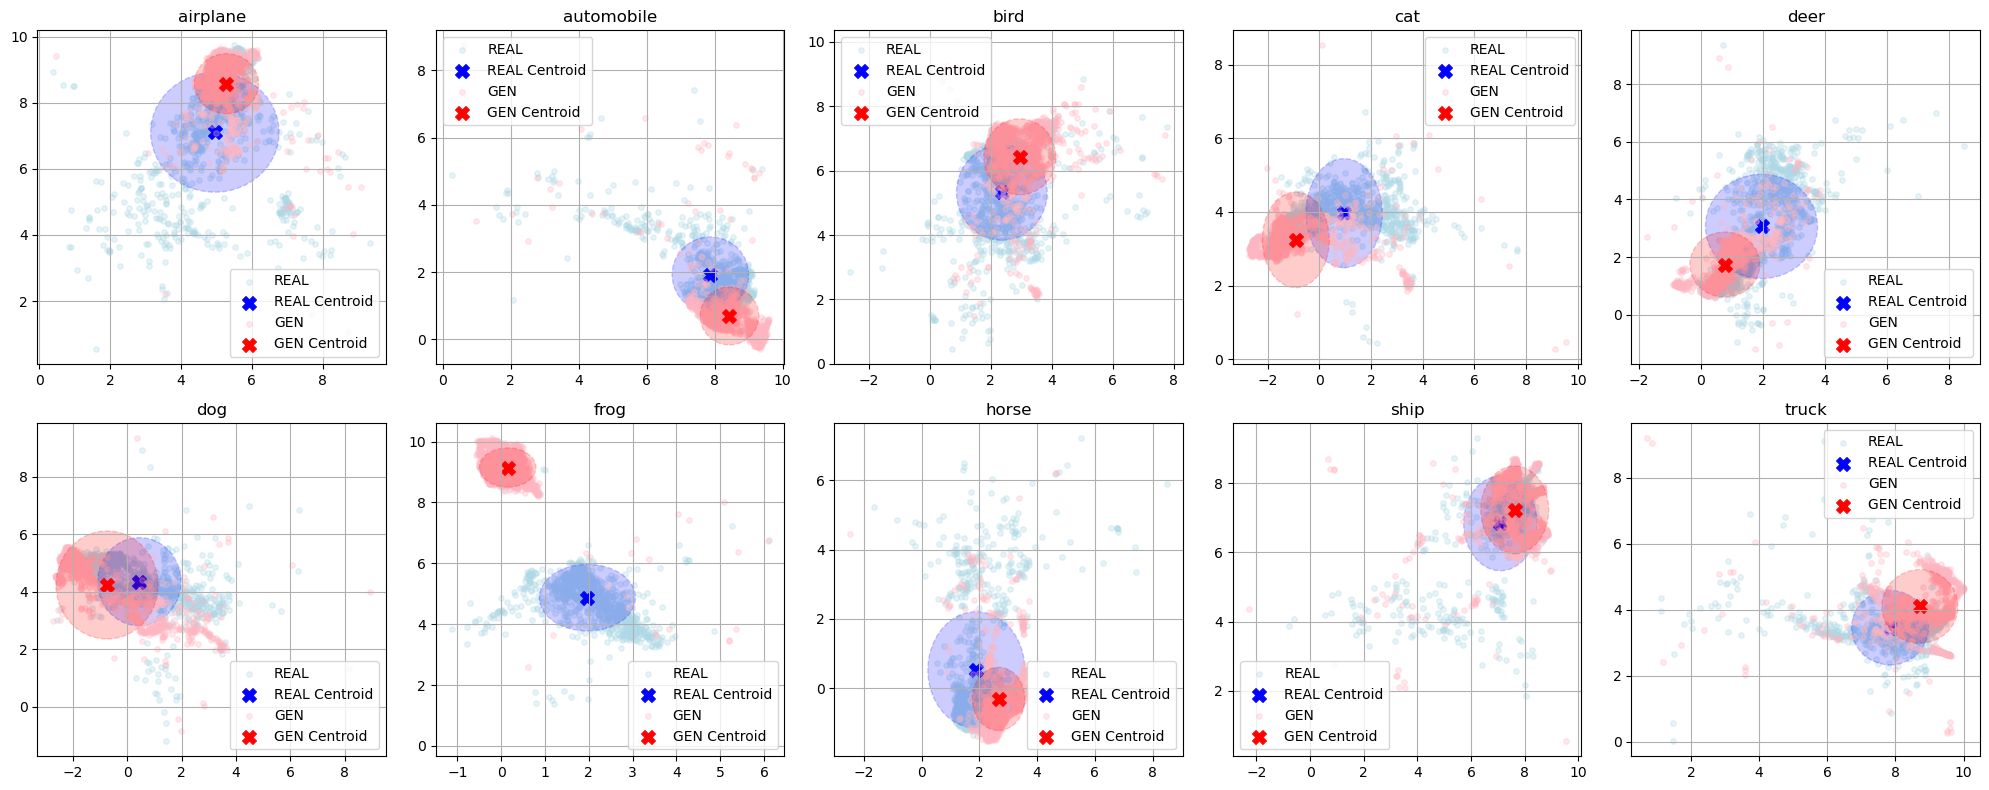

In [15]:
model_name = 'CLIP'
reducer_name = 'UMAP'
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine")

embeddings_2d = reduce_dim(reducer, model_name, reducer_name)
plot_2d_embeddings(embeddings_2d, model_name, reducer_name)
save_distance(embeddings_2d, model_name, reducer_name)

/home/kuniko/anaconda3/lib/python3.11/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


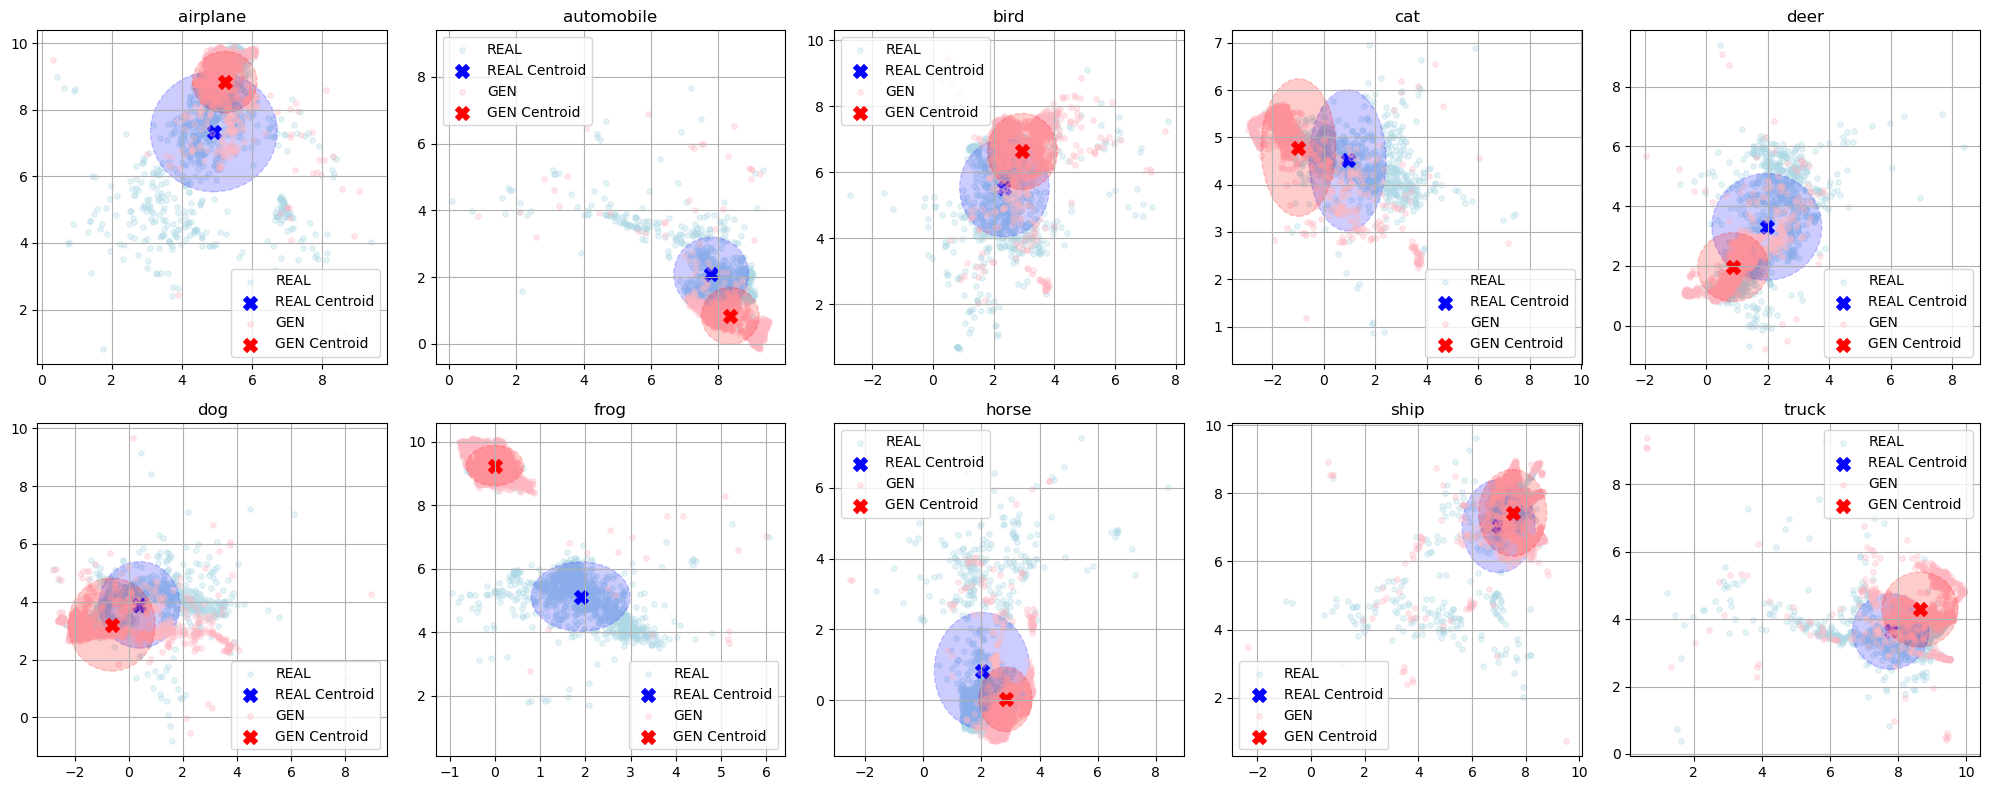

In [16]:
model_name = 'CLIP'
reducer_name = 'TSNE'
tsne = TSNE(n_components=2, perplexity=30, metric="cosine", random_state=42)

embeddings_2d = reduce_dim(reducer, model_name, reducer_name)
plot_2d_embeddings(embeddings_2d, model_name, reducer_name)
save_distance(embeddings_2d, model_name, reducer_name)